In [ ]:
!pip install pillow

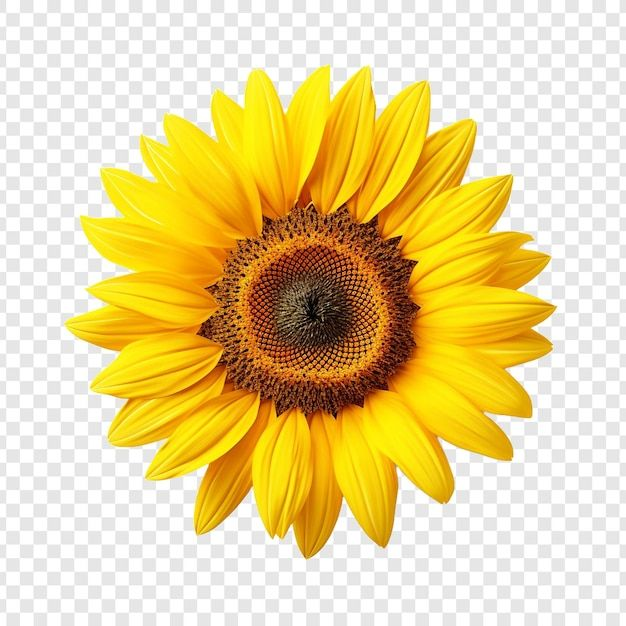

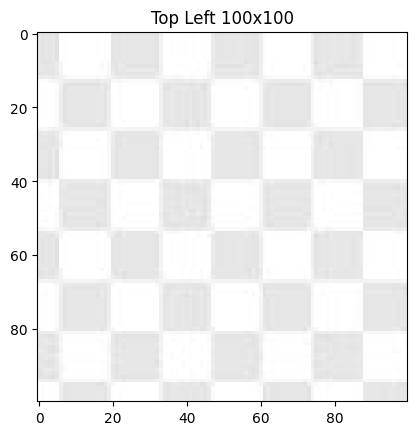

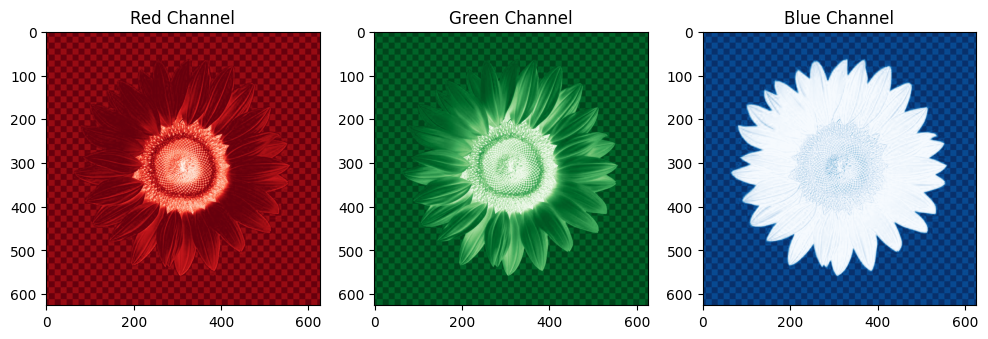

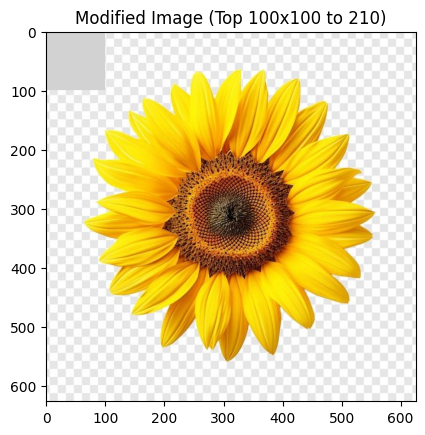

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. Read and display the image
# Make sure you have uploaded 'test.jpg' to the folder icon on the left
img = Image.open('test.jpg')
display(img) # Use display() for Colab [cite: 262, 265]

# Convert to NumPy array for matrix operations [cite: 362]
img_array = np.array(img)

# 2. Display top left corner (100x100 pixels) [cite: 26]
# Slicing: [rows, columns, channels] [cite: 482]
top_left = img_array[:100, :100, :]
plt.imshow(top_left)
plt.title("Top Left 100x100")
plt.show()

# 3. Show three color channels (R, G, B) [cite: 28, 29]
plt.figure(figsize=(12, 4))
titles = ['Red Channel', 'Green Channel', 'Blue Channel']
cmaps = ['Reds', 'Greens', 'Blues'] # Matplotlib colormaps [cite: 44]

for i in range(3):
    plt.subplot(1, 3, i+1)
    # index 0=Red, 1=Green, 2=Blue [cite: 386, 387]
    plt.imshow(img_array[:, :, i], cmap=cmaps[i])
    plt.title(titles[i])
plt.show()

# 4. Modify top 100x100 pixels to value 210 (light gray) [cite: 30]
modified_img = img_array.copy()
modified_img[:100, :100, :] = 210
plt.imshow(modified_img)
plt.title("Modified Image (Top 100x100 to 210)")
plt.show()

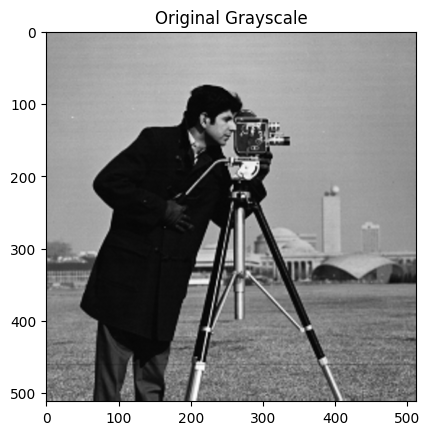

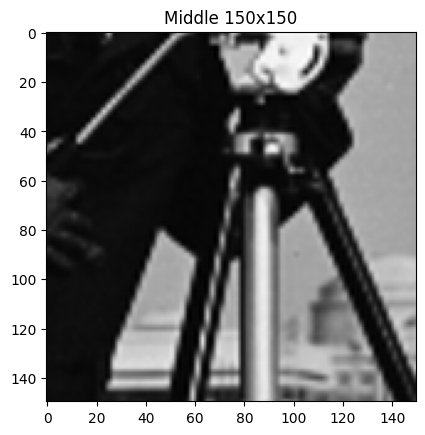

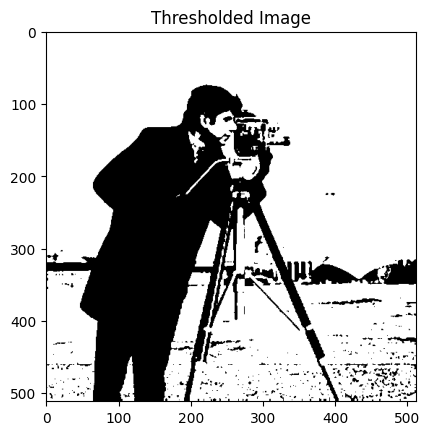

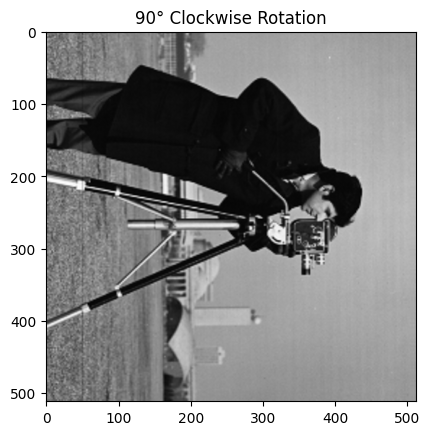

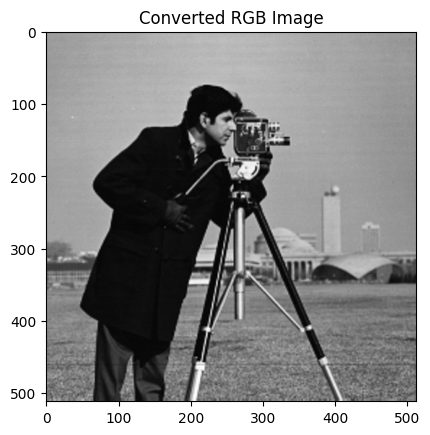

In [ ]:
# 1. Load and display grayscale image [cite: 56, 57]
gray_img = Image.open('cameraman.png').convert('L') # 'L' mode is grayscale [cite: 86]
gray_array = np.array(gray_img)
plt.imshow(gray_array, cmap='gray')
plt.title("Original Grayscale")
plt.show()

# 2. Extract middle 150x150 section [cite: 59, 60]
h, w = gray_array.shape
center_h, center_w = h // 2, w // 2
middle = gray_array[center_h-75:center_h+75, center_w-75:center_w+75]
plt.imshow(middle, cmap='gray')
plt.title("Middle 150x150")
plt.show()

# 3. Apply threshold (values < 100 to 0, others to 255) [cite: 62, 63]
thresholded = np.where(gray_array < 100, 0, 255)
plt.imshow(thresholded, cmap='gray')
plt.title("Thresholded Image")
plt.show()

# 4. Rotate 90 degrees clockwise [cite: 65, 66]
rotated = gray_img.rotate(-90)
plt.imshow(rotated, cmap='gray')
plt.title("90° Clockwise Rotation")
plt.show()

# 5. Convert grayscale to RGB (replicate across channels) [cite: 68, 69]
rgb_converted = np.stack([gray_array] * 3, axis=-1)
plt.imshow(rgb_converted)
plt.title("Converted RGB Image")
plt.show()

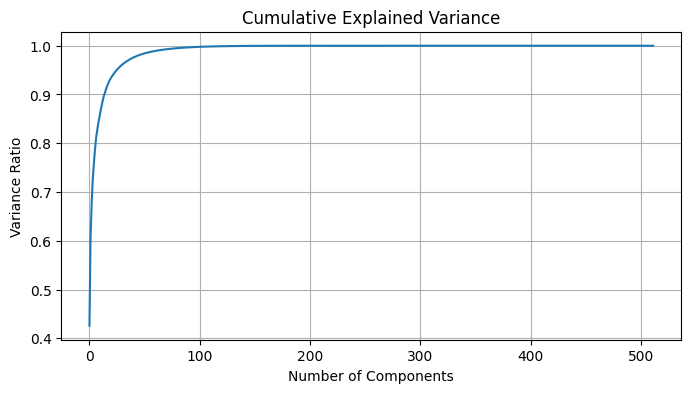

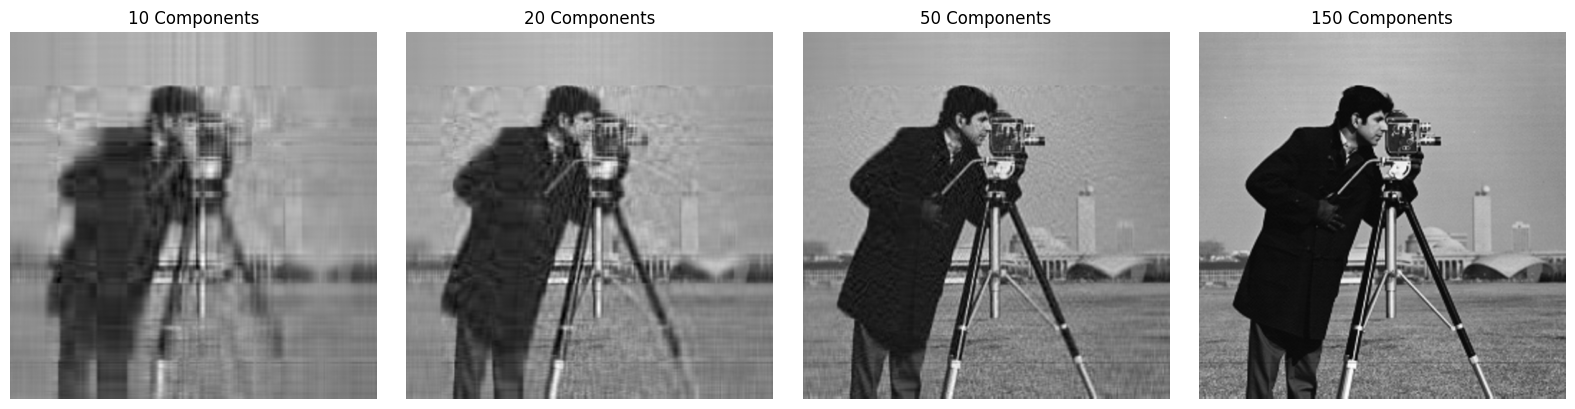

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# --- STEP 0: Load and Prepare Data ---
# 1. Input your image file name here
img_path = 'cameraman.png'

# 2. Load the image and convert to grayscale if it isn't already [cite: 86, 585]
image = Image.open(img_path).convert("L")

# 3. Convert to NumPy array and define 'data' [cite: 587, 595]
image_array = np.array(image)
data = image_array.astype(np.float64)

# --- STEP 1: Standardize the Data ---
# Subtract mean from each pixel to center the data [cite: 87, 608]
mean = np.mean(data, axis=0)
centered_data = data - mean

# --- STEP 2: Compute Covariance Matrix ---
# The covariance matrix captures relationships between pixels [cite: 88, 620]
cov_matrix = np.cov(centered_data, rowvar=False)

# --- STEP 3: Eigen Decomposition ---
# Compute eigenvalues and eigenvectors [cite: 89, 633]
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort eigenvalues and vectors in descending order [cite: 91, 636]
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# --- STEP 4: Identification & Cumulative Sum Plot ---
# Identify Principal Components with the help of cumulative Sum plot [cite: 92, 660]
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(eigenvalues) / np.sum(eigenvalues))
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Variance Ratio")
plt.grid(True)
plt.show()

# --- STEP 5: Reconstruction and Experiment ---
# Transform original data using selected eigenvectors to get lower-dimensional representation [cite: 94]
def reconstruct(k):
    # Select top k principal components [cite: 91, 699]
    components = eigenvectors[:, :k]
    # Forward Transform (Compression) [cite: 712]
    compressed = np.dot(centered_data, components)
    # Reverse Transform (Decompression/Reconstruction) [cite: 743]
    reconstructed = np.dot(compressed, components.T) + mean
    return reconstructed

# Experiments: Pick Four different combinations of components [cite: 95]
plt.figure(figsize=(16, 4))
ks = [10, 20, 50, 150]
for i, k in enumerate(ks):
    plt.subplot(1, 4, i+1)
    plt.imshow(reconstruct(k), cmap='gray')
    plt.title(f"{k} Components")
    plt.axis('off')
plt.tight_layout()
plt.show()